```text id="34m1g5"
✅ 1. Project Setup & Imports
✅ 2. Load Config & LLM
✅ 3. Understand Parallel Workflow Pattern
✅ 4. Create Research Node
✅ 5. Test Research Node
✅ 6. Create Keyword Node
✅ 7. Test Keyword Node
✅ 8. Create Merge Node
✅ 9. Test Merge Node
✅ 10. Create StateGraph
✅ 11. Add All Nodes
✅ 12. Create Parallel Edges
✅ 13. Compile Graph
✅ 14. Invoke Graph
✅ 15. Visualize Parallel Workflow
✅ 16. Understand Fan-Out / Fan-In
✅ 17. Final Recap
```

In [2]:
# ==========================================
# Notebook 3: Parallel Workflows
# Project Setup & Imports
# ==========================================

import os
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Root Added Successfully")
print(PROJECT_ROOT)

Project Root Added Successfully
d:\projects\python\stepIntoAI\LangGraph-Crash-Course


In [3]:
# ==========================================
# Load Config, LLM & LangGraph Components
# ==========================================

from src.utils.config_loader import load_config
from src.utils.model_loader import load_llm

from langgraph.graph import StateGraph
from langgraph.graph import START
from langgraph.graph import END

from src.states.state_schema import GraphState

config = load_config()
llm = load_llm()

print("Configuration Loaded Successfully")
print("LLM Loaded Successfully")
print(type(llm))

Configuration Loaded Successfully
LLM Loaded Successfully
<class 'langchain_openai.chat_models.base.ChatOpenAI'>


In [3]:
# ==========================================
# Understanding Parallel Workflows
# ==========================================

parallel_workflow = """
                 ┌───────────── Research Node
User Query ──────┤
                 │
                 └───────────── Keyword Node

                           ↓

                      Merge Node

                           ↓

                          END
"""

print(parallel_workflow)


                 ┌───────────── Research Node
User Query ──────┤
                 │
                 └───────────── Keyword Node

                           ↓

                      Merge Node

                           ↓

                          END



In [4]:
# ==========================================
# Research Node
# ==========================================

def research_node(state: GraphState):
    print("\n--- Research Node Executed ---")
    response = llm.invoke(
        f"""
        Write 5 concise lines about:

        {state['user_query']}
        """
    )
    return {"research_notes": response.content}


print("Research Node Created Successfully")

Research Node Created Successfully


In [5]:
# ==========================================
# Test Research Node
# ==========================================

test_state = {"user_query": "LangGraph"}

result = research_node(test_state)

print("\nResearch Notes:\n")
print(result["research_notes"])


--- Research Node Executed ---

Research Notes:

LangGraph is a language processing tool designed to analyze and visualize linguistic data. It leverages advanced algorithms to map relationships between words and phrases. The platform supports multiple languages, enhancing cross-linguistic research. Users can explore semantic networks and syntactic structures interactively. LangGraph is valuable for linguists, educators, and AI developers seeking insights into language patterns.


In [ ]:
# ==========================================
# Keyword Node
# ==========================================

def keyword_node(state: GraphState):
    print("\n--- Keyword Node Executed ---")
    response = llm.invoke(
        f"""
        Extract the 5 most relevant technical keywords
        related to the topic below.

        Topic:
        {state['user_query']}

        Return only the keywords separated by commas.

        Example:
        LangGraph, StateGraph, Nodes, Edges, Workflows
        """
    )
    keywords = [
        keyword.strip()
        for keyword in response.content.split(",")
    ]
    return {"keywords": keywords}


print("Keyword Node Created Successfully")

Keyword Node Created Successfully


In [7]:
# ==========================================
# Test Keyword Node
# ==========================================

test_state = {"user_query": "LangGraph"}
result = keyword_node(test_state)

print("\nKeywords:\n")
print(result["keywords"])


--- Keyword Node Executed ---

Keywords:

['LangGraph', 'keywords', 'extract', 'important', 'comma-separated']


In [8]:
# ==========================================
# Merge Node
# ==========================================

def merge_node(state: GraphState):
    print("\n--- Merge Node Executed ---")
    summary = f"""
            Research Notes:
            {state['research_notes']}

            Keywords:
            {', '.join(state['keywords'])}
            """
    return {"summary": summary}

print("Merge Node Created Successfully")

Merge Node Created Successfully


In [9]:
# ==========================================
# Test Merge Node
# ==========================================

test_state = {
    "research_notes":
    "LangGraph is a framework for building stateful workflows.",

    "keywords":
    ["LangGraph", "State", "Workflow"]
}

result = merge_node(test_state)

print("\nMerged Summary:\n")
print(result["summary"])


--- Merge Node Executed ---

Merged Summary:


            Research Notes:
            LangGraph is a framework for building stateful workflows.

            Keywords:
            LangGraph, State, Workflow
            


In [10]:
# ==========================================
# Create StateGraph
# ==========================================
builder = StateGraph(GraphState)
print("StateGraph Created Successfully")

StateGraph Created Successfully


In [11]:
# ==========================================
# Add Nodes
# ==========================================
builder.add_node("research_node", research_node)
builder.add_node("keyword_node", keyword_node)
builder.add_node("merge_node", merge_node)

print("All Nodes Added Successfully")

All Nodes Added Successfully


In [12]:
# ==========================================
# Create Parallel Workflow
# ==========================================
builder.add_edge(START, "research_node")
builder.add_edge(START, "keyword_node")
builder.add_edge("research_node", "merge_node")
builder.add_edge("keyword_node", "merge_node")
builder.add_edge("merge_node", END)

print("Parallel Workflow Created Successfully")

Parallel Workflow Created Successfully


In [13]:
# ==========================================
# Compile Parallel Graph
# ==========================================

graph = builder.compile()

print("Graph Compiled Successfully")
print(type(graph))

Graph Compiled Successfully
<class 'langgraph.graph.state.CompiledStateGraph'>


In [ ]:
# ==========================================
# Invoke Parallel Graph
# ==========================================

result = graph.invoke({"user_query": "What is LangGraph?"})
print("\nFinal State:\n")

for key, value in result.items():
    print(f"\n{key}:")
    if isinstance(value, list):
        print(value)
    else:
        print(value)


--- Keyword Node Executed ---
--- Research Node Executed ---


--- Merge Node Executed ---

Final State:


user_query:
What is LangGraph?

keywords:
['LangGraph', 'keywords', 'extract', 'important', 'comma-separated']

research_notes:
LangGraph is a language processing framework designed to analyze and visualize linguistic data. It leverages graph-based models to represent relationships between words and phrases. The tool aids in understanding complex language structures and semantic connections. It is used in natural language processing (NLP) tasks to enhance language comprehension. LangGraph supports various applications, including text analysis, sentiment analysis, and machine translation.

summary:

            Research Notes:
            LangGraph is a language processing framework designed to analyze and visualize linguistic data. It leverages graph-based models to represent relationships between words and phrases. The tool aids in understanding complex language structures and s

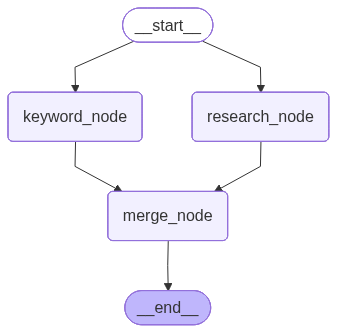

In [15]:
# ==========================================
# Visualize Parallel Workflow
# ==========================================

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
# ==========================================
# Fan-Out / Fan-In Demonstration
# ==========================================

print("""
Parallel Workflow Pattern

                START
                   |
        ---------------------
        |                   |
        v                   v

 Research Node      Keyword Node

        |                   |
        ---------------------
                   |
                   v

              Merge Node
                   |
                   v
                  END


Fan-Out:
One state becomes multiple branches.

Fan-In:
Multiple branches merge back into one branch.
""")


Parallel Workflow Pattern

                START
                   |
        ---------------------
        |                   |
        v                   v

 Research Node      Keyword Node

        |                   |
        ---------------------
                   |
                   v

              Merge Node
                   |
                   v
                  END


Fan-Out:
One state becomes multiple branches.

Fan-In:
Multiple branches merge back into one branch.



In [17]:
# ==========================================
# Notebook 3 Recap
# ==========================================

print("""
Key Learnings ->

1. LangGraph supports parallel execution.
2. One node is not required to wait for another.
3. Multiple branches can execute independently.
4. Fan-Out creates parallel branches.
5. Fan-In merges parallel branches.
6. Shared state enables communication between branches.
7. Parallel workflows are useful for:
   - Research Pipelines
   - Multi-Agent Systems
   - Information Gathering
   - Large Scale Agentic Workflows
""")


Key Learnings ->

1. LangGraph supports parallel execution.
2. One node is not required to wait for another.
3. Multiple branches can execute independently.
4. Fan-Out creates parallel branches.
5. Fan-In merges parallel branches.
6. Shared state enables communication between branches.
7. Parallel workflows are useful for:
   - Research Pipelines
   - Multi-Agent Systems
   - Information Gathering
   - Large Scale Agentic Workflows

